# 17 — Units

**The concept:** a unit usually lives only in a variable's *name* (`_db`, `_km`, `_ms`), where
nothing reads it. dB wired into linear, kilometres into metres, milliseconds into seconds: none of
these fail. They produce a number, and the number converges.

SmartMDAO lets you **declare** a unit in the annotation, and `validate()` reports a connection whose
two ends disagree. Three rules govern the whole feature:

1. **Nothing is ever converted.** A mismatch is reported; the value is left exactly as it is.
2. **A missing unit is not an error.** A connection is checked only when both ends declare one.
3. **Units are read, never run.** They come from annotations, like every other analysis.

In [1]:
import matplotlib
matplotlib.use("Agg", force=True)

import pathlib, tempfile
from typing import Annotated
from IPython.display import Image
from smartmdao import Pipeline, Unit, validate, explain

gallery = pathlib.Path(tempfile.mkdtemp())

def show(pipeline, name):
    path = gallery / f"{name}.png"
    pipeline.visualize(output_path=str(path), view=False)
    return Image(filename=str(path))

## Declaring a unit

A unit is a `Unit` marker inside `Annotated`. An alias keeps signatures readable. Here an antenna
produces a gain **in dB**, and a link budget reads it as if it were **linear**:

In [2]:
dB = Annotated[float, Unit("dB")]
linear = Annotated[float, Unit("linear")]

link = Pipeline(inputs=["power"])

@link.step(outputs=["gain"])
def antenna(power: Annotated[float, Unit("W")]) -> dB:
    return 10.0

@link.step(outputs=["margin"])
def budget(gain: linear) -> float:
    return gain - 3.0

for finding in validate(link):
    print(finding)

ERROR: 'antenna' produces gain in dB, but 'budget' expects it in linear. Nothing is converted, so the value would be read in the wrong unit. One side is logarithmic: the two differ by a logarithm, not a factor. [budget]


An **error**, like a type mismatch: the pipeline's own declarations contradict each other. Because
one side is logarithmic, the message adds that the two differ by a logarithm, not by a factor.

And **nothing was converted**. The run gives exactly the number it would give with no units at all:
the mistake is reported, not silently repaired.

In [3]:
print("margin:", link.run(power=1.0)["margin"])

margin: 7.0


The diagram shows the units, and draws the mismatched connection the way it draws a missing input:

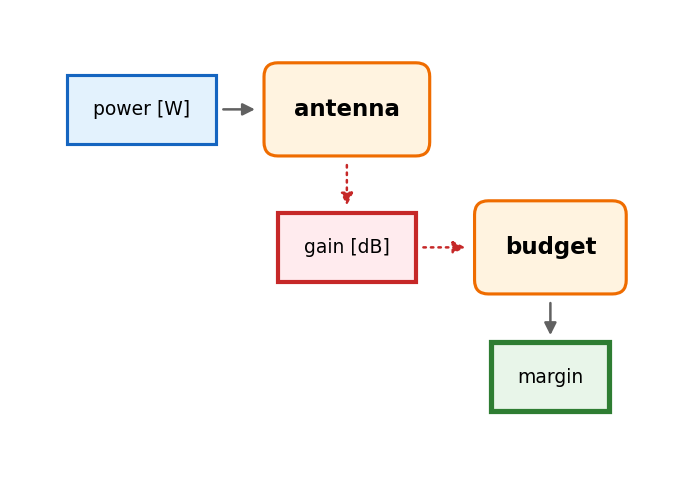

In [4]:
show(link, "link")

## One external input, two opinions

Nothing produces an external input, so there is no producer to compare with. But two steps reading
it can still disagree, and one value cannot be in both units.

In [5]:
route = Pipeline(inputs=["distance"])

@route.step(outputs=["delay"])
def latency(distance: Annotated[float, Unit("m")]) -> float:
    return distance / 3e8

@route.step(outputs=["cost"])
def price(distance: Annotated[float, Unit("km")]) -> float:
    return distance * 0.1

for finding in validate(route):
    print(finding)

ERROR: External input 'distance' is expected in m by 'latency' and in km by 'price'. One value cannot be both. [distance]


The same check now applies to **types**. Two consumers declaring `float` and `str` for one input
used to pass `validate()` and fail only at `run()`, once a value was passed. It is reported before
anything runs:

In [6]:
typed = Pipeline(inputs=["distance"])

@typed.step(outputs=["delay"])
def latency(distance: float) -> float:
    return distance / 3e8

@typed.step(outputs=["label"])
def tag(distance: str) -> str:
    return distance

for finding in validate(typed):
    print(finding)

ERROR: External input 'distance' is declared float by 'latency' and str by 'tag': no single value can satisfy both, so run() will refuse whatever is passed. [distance]


## What is not a unit, and what is not checked

Only a `Unit` marker counts. `Annotated` metadata is shared with other libraries and with plain
descriptions, and reading a description as a unit would be a guess. A connection with a unit on only
one end is **unchecked**. `explain()` says how much of the pipeline actually is checked:

In [7]:
partial = Pipeline(inputs=["span"])

@partial.step(outputs=["area"])
def wing(span: Annotated[float, "the wing span, tip to tip"]) -> Annotated[float, Unit("m2")]:
    return span * 1.5                       # the description above is not a unit

@partial.step(outputs=["lift"])
def aero(area: Annotated[float, Unit("m2")]) -> float:
    return area * 900.0

@partial.step(outputs=["load"])
def structure(lift: Annotated[float, Unit("N")]) -> float:   # lift has no unit where it is made
    return lift / 9.81

print("findings:", validate(partial))
print([line for line in explain(partial).splitlines() if line.startswith("Units")][0])

findings: ()
Units: 1 of 2 connections between steps checked.


## "The same unit" means exactly the same

`km` into `m` is reported, and so is `meter` into `m`: SmartMDAO does not guess that two spellings
mean the same thing. `dB` and `dBm` look close and differ by a reference power. If your project wants
more — aliases, or a unit library's dimensional analysis — give the pipeline its own `unit_checker`:
anything with a `consistent(produced, expected)` method satisfies the `UnitChecker` protocol, and
replaces the default `StandardUnitChecker`. It answers yes or no, and has no way to rescale a value.

In [8]:
class Aliases:
    SAME = [{"m", "meter"}, {"s", "sec"}]

    def consistent(self, produced: str, expected: str) -> bool:
        return produced == expected or {produced, expected} in self.SAME

spelled = Pipeline(inputs=["x"])

@spelled.step(outputs=["length"])
def measure(x: float) -> Annotated[float, Unit("meter")]:
    return x

@spelled.step(outputs=["area"])
def square(length: Annotated[float, Unit("m")]) -> float:
    return length ** 2

from smartmdao import StandardUnitChecker, UnitChecker

print("default:", type(spelled.unit_checker).__name__, "| Aliases is a UnitChecker:", isinstance(Aliases(), UnitChecker))
print("exact:  ", [f.code for f in validate(spelled)])
spelled.unit_checker = Aliases()
print("aliases:", [f.code for f in validate(spelled)])

default: StandardUnitChecker | Aliases is a UnitChecker: True
exact:   ['unit-mismatch']
aliases: []


In [9]:
import shutil
shutil.rmtree(gallery)
print("cleaned up")

cleaned up


---

Why it is built this way — a marker rather than a string, exact match, and never a conversion — is
[design record 008](../docs/design/008-units.md).

**Back to** [the index](README.md).